# Computer Vision 
## Notebook 4a — DINOv3 Domain-Adaptive Pretraining on VisioDECT

| | |
|---|---|
| **Dataset** | **VisioDECT** (Part A cleaned image set, 20,603 images, labels **discarded** for SSL) |
| **SSL method** | **DINOv3** — frozen ViT-B/16 teacher (released LVD-1689M weights) **distilled** into the CNN student on our domain |
| **Student** | Backbone of **YOLOv26-s** (Part A best) — receives the distilled features |
| **Framework** | `ssl-detection-lab` >= 0.8.1 + `lightly-train[ultralytics]` (exactly as in the course tutorial) |
| **Downstream pair** | Notebook 4b loads the exported YOLO student and fine-tunes at the 20% label budget |

**Covers step in order**, plus the two DINOv3-specific mandates:
the **integration-route statement** (route 2: distillation into the CNN backbone) and the
**domain-adaptive-pretraining declaration** with its fairness caveat for the report.

## 0. How to Run This Notebook on Kaggle
1. **Create**: Kaggle → *Create* → *New Notebook* → File → Import Notebook. Accelerator =
   **GPU T4 x2**; Internet = **On** (pip installs only).
2. **Attach TWO inputs** (*Add Input*):
   - **Part A Notebook 1's output** (`visiodect_yolo/`) — the images to merge and
     re-partition 10/10/80 with the shared seed;
   - the **DINOv3 ViT-B/16 weights dataset** — the course-provided
     `mrifatrashid/dinov3-weigths` (file `dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth`),
     or your own copy of the same file. The official DINOv3 release is licence-gated on
     HuggingFace, so the course path is a **local attached checkpoint** — the tutorial (and
     this notebook) deliberately refuse to fall back to silent downloads.
3. **Version gate (course announcement)**: the install cell must print
   `ssl-detection-lab version: 0.8.1` **or newer** — if older, *Run → Restart & clear cell
   outputs* and rerun from the top.
4. **Run all.** §6's 1-epoch probe prints a 50-epoch estimate before the real run.
5. **Commit**, set **Public**, then add this notebook's output files to the group's
   checkpoint dataset (`groupXX-partb-ssl-checkpoints`) so Notebook 4b can attach
   `dinov3_yolo26s_backbone.pt` and the shared `partB_partition.csv`.

## 1. CONFIG
Everything §4.1 requires, plus the two statements the DINOv3 section of the assignment
demands — read the two comment blocks marked VIVA.

In [ ]:
# =============================== CONFIG ===============================

# ---- method: DINOv3 distillation ----------------------------------------
SSL_METHOD    = "dinov3"
TEACHER_MODEL = "dinov3/vitb16"          # frozen ViT-B/16 teacher (LightlyTrain registry)
STUDENT_MODEL = "ultralytics/yolo26s.yaml"   # Part A best architecture, random init
# VIVA — integration route (assignment "Backbone Integration Strategy"):
# DINOv3 is ViT-based, so we use ROUTE 2 — DISTILLATION INTO THE CNN: the frozen
# ViT-B/16 teacher's dense features supervise the YOLOv26-s student backbone via
# LightlyTrain's distillation objective on OUR unlabelled pool. Trade-off vs the
# ViT+adapter route: we keep the exact deployment CNN (weights load layer-for-
# layer in 4b, same surgery as I-JEPA) and inherit the teacher's semantics, but
# give up the ViT's own capacity at inference time.
# VIVA — domain-adaptive declaration (assignment permits this for DINOv3 only):
# the teacher starts from the RELEASED LVD-1689M pretrained weights and the
# adaptation to VisioDECT happens in the student on our 80% pool. This must be
# reported as DOMAIN-ADAPTIVE PRETRAINING, and the fairness caveat stated: unlike
# SimCLR/BYOL/I-JEPA (trained from scratch on our pool), DINOv3's backbone
# inherits web-scale knowledge — the report's comparison table carries this note.

# ---- Part B shared partition protocol (IDENTICAL to Notebook 3a) ---------
PARTB_SEED   = 445
TEST_FRAC    = 0.10
VAL_FRAC     = 0.10

# ---- pretraining budget (assignment standard: 30 epochs) ------------------
FAST_RUN     = False
EPOCHS       = 50       # assignment standard for every SSL pretraining run
IMAGE_SIZE   = 224      # tutorial preset; ViT-B/16 -> 14x14 patch tokens
BATCH_SIZE   = 32       # tutorial full preset; if the T4 OOMs with the ViT-B
                        # teacher in memory, drop to 16 and document it here
WORKERS      = 4
DEVICES      = 1        # per the course tutorial: LightlyTrain distillation runs
                        # single-GPU in notebooks (teacher forward dominates);
                        # the second T4 stays idle — documented budget decision
PRECISION    = "16-mixed"   # fp16 on T4 tensor cores (Part A lesson: NEVER bf16
                            # on a T4 — it is emulated and ~2x slower)

TIMING_PROBE = True
NB1_DIR_MANUAL     = None
TEACHER_WEIGHTS_MANUAL = None   # e.g. Path(".../dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth")
WORK_ROOT    = "/kaggle/working"
SSL_POOL_DIR = f"{WORK_ROOT}/ssl_pool"
OUTPUT_DIR   = f"{WORK_ROOT}/dinov3_yolo26s_visiodect"
PROBE_DIR    = f"{WORK_ROOT}/dinov3_probe"
PARTITION_CSV = f"{WORK_ROOT}/partB_partition.csv"
CKPT_BACKBONE = f"{WORK_ROOT}/dinov3_backbone.pt"           # §7 naming convention
CKPT_YOLO     = f"{WORK_ROOT}/dinov3_yolo26s_backbone.pt"   # what 4b's surgery loads

if FAST_RUN:
    EPOCHS, IMAGE_SIZE, BATCH_SIZE = 2, 160, 8

print(f"CONFIG | {SSL_METHOD}: {TEACHER_MODEL} -> {STUDENT_MODEL} | {EPOCHS} epochs "
      f"@ {IMAGE_SIZE}px | batch {BATCH_SIZE} | {PRECISION} | seed {PARTB_SEED}")


CONFIG | dinov3: dinov3/vitb16 -> ultralytics/yolo26s.yaml | 50 epochs @ 224px | batch 32 | 16-mixed | seed 445


## 2. Environment — course package + LightlyTrain, with the version gate
Two installs, exactly as the course tutorial: `lightly-train[ultralytics]` provides the
distillation engine; `ssl-detection-lab` provides the validated DINOv3→YOLO26 wrapper. The
gate must print **0.8.1 or newer** — restart and rerun if not.

In [2]:
%pip install -q -U "lightly-train[ultralytics]>=0.16.2"
%pip install -q --no-cache-dir --force-reinstall --no-deps "git+https://github.com/rifat963/ssl-detection-lab.git@main"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 975.0/975.0 kB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 891.2/891.2 kB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.8/155.8 kB 12.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
from dataclasses import replace
from importlib.metadata import version as installed_version
import json, random, shutil, time, os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
import torch
import torch.nn.functional as F
from PIL import Image
from packaging.version import Version
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import v2
from tqdm.auto import tqdm
from ultralytics import YOLO
import lightly_train

_v = installed_version("ssl-detection-lab")
print(f"ssl-detection-lab version: {_v}")
assert Version(_v) >= Version("0.8.1"), (
    "Older ssl-detection-lab detected. Per the course announcement: restart the "
    "session (Run -> Restart & clear cell outputs) and rerun the install cell first.")

import ssldet
from ssldet import DINOv3YOLOConfig, pretrain_dinov3_yolo26, validate_dinov3_yolo26_support
from ssldet.backbones import YOLOBackboneEncoder
from ssldet.data import IMAGENET_MEAN, IMAGENET_STD, UnlabeledImageDataset

random.seed(PARTB_SEED); np.random.seed(PARTB_SEED)
torch.manual_seed(PARTB_SEED); torch.cuda.manual_seed_all(PARTB_SEED)
torch.set_float32_matmul_precision("high")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(pd.Series({"ssl-detection-lab": ssldet.__version__, "PyTorch": torch.__version__,
                 "LightlyTrain": getattr(lightly_train, "__version__", "unknown"),
                 "GPU": torch.cuda.get_device_name(0) if torch.cuda.is_available()
                        else "CPU (smoke only)"}))


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ssl-detection-lab version: 0.9.0
ssl-detection-lab           0.9.0
PyTorch              2.10.0+cu128
LightlyTrain               0.17.0
GPU                      Tesla T4
dtype: object


## 3. Locate the DINOv3 Teacher Weights & Validate Support
The tutorial's rule is enforced: the **local attached checkpoint is required** — no silent
download fallback. `validate_dinov3_yolo26_support` confirms LightlyTrain recognises the
teacher, the YOLOv26-s student, and the distillation method before any training.

In [4]:
def find_teacher_weights():
    if TEACHER_WEIGHTS_MANUAL is not None:
        p = Path(TEACHER_WEIGHTS_MANUAL)
        assert p.is_file(), f"Manual teacher-weights path missing: {p}"
        return p
    stack = [(Path("/kaggle/input"), 0)]
    while stack:
        d, dep = stack.pop()
        try:
            for c in d.iterdir():
                if c.is_file() and c.name.startswith("dinov3_vitb16") and c.suffix == ".pth":
                    return c
                if c.is_dir() and dep < 5:
                    stack.append((c, dep + 1))
        except (PermissionError, OSError):
            pass
    raise FileNotFoundError(
        "DINOv3 ViT-B/16 weights (.pth) not found under /kaggle/input — attach the "
        "course dataset 'mrifatrashid/dinov3-weigths' (Section 0 step 2).")

TEACHER_WEIGHTS = find_teacher_weights()
support = validate_dinov3_yolo26_support(
    lightly_train, teacher_model=TEACHER_MODEL, student_model=STUDENT_MODEL)
print(pd.Series({
    "teacher weights": str(TEACHER_WEIGHTS),
    "teacher weights MB": round(TEACHER_WEIGHTS.stat().st_size / 1024**2, 1),
    "teacher available": support[TEACHER_MODEL],
    "student available": support[STUDENT_MODEL],
    "distillation available": support["distillation"],
}))
assert all(support.values()), "LightlyTrain does not support this teacher/student pair!"


teacher weights           /kaggle/input/datasets/mrifatrashid/dinov3-wei...
teacher weights MB                                                    327.0
teacher available                                                      True
student available                                                      True
distillation available                                                 True
dtype: object


## 4. Leakage-Safe 10/10/80 Partition (shared by every SSL notebook)
The Part A splits are **not reused**: all 20,603 cleaned images are merged and re-partitioned
once, at image level, with the shared seed — 10% test holdout, 10% validation, 80% SSL pool.
This cell **prints the partition sizes** and **verifies by filename intersection** that test
and validation are disjoint from the SSL pool (both are assignment mandates). It also assigns
every pool image a seeded `pool_rank`, so the 20% fine-tuning subset (Notebook 3b) and the
bonus 10–50% budgets are **nested by construction** — budget ρ is simply
`pool_rank < ρ·|D|`. The manifest is exported for hand-off so every notebook provably uses
the identical partition.

**Why this is not leakage :** SSL pretraining never reads annotations, so no label
information can leak; fine-tuning images legitimately overlap the SSL pool (the standard
SimCLR/BYOL label-efficiency protocol); leakage would require test/val pixels in the pool,
labels influencing pretraining, or test-driven tuning — the checks below rule out the first
and the pipeline never does the other two.


In [5]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def find_nb1_root():
    if NB1_DIR_MANUAL is not None:
        p = Path(NB1_DIR_MANUAL)
        if (p / "train" / "images").exists():
            return p
        raise FileNotFoundError(f"Manual path is not the NB1 output: {p}")
    base, stack = Path("/kaggle/input"), []
    stack.append((base, 0))
    while stack:
        d, dep = stack.pop()
        if d.name == "visiodect_yolo" and (d / "train" / "images").exists():
            return d
        if dep < 4:
            try:
                stack += [(c, dep + 1) for c in d.iterdir() if c.is_dir()]
            except (PermissionError, OSError):
                pass
    raise FileNotFoundError("Attach Part A Notebook 1's OUTPUT (visiodect_yolo/) as input.")

NB1_ROOT = find_nb1_root()
all_images = sorted(p for s in ("train", "val", "test")
                    for p in (NB1_ROOT / s / "images").rglob("*")
                    if p.is_file() and p.suffix.lower() in IMG_EXTS)
N = len(all_images)
print(f"NB1 root: {NB1_ROOT}\nMerged Part A images: {N:,}")

# ---- one seeded shuffle drives everything -----------------------------------
names = [p.name for p in all_images]
assert len(set(names)) == N, "filename collision across NB1 splits!"
order = list(range(N))
random.Random(PARTB_SEED).shuffle(order)
n_test, n_val = round(TEST_FRAC * N), round(VAL_FRAC * N)
test_idx = set(order[:n_test])
val_idx  = set(order[n_test:n_test + n_val])
pool_pos = order[n_test + n_val:]                 # shuffled order -> nested budgets

rows, pool_rank = [], {i: r for r, i in enumerate(pool_pos)}
for i, p in enumerate(all_images):
    part = "test" if i in test_idx else "val" if i in val_idx else "ssl_pool"
    rows.append({"filename": p.name, "source_path": str(p), "partition": part,
                 "pool_rank": pool_rank.get(i, -1)})
partition = pd.DataFrame(rows)
partition.to_csv(PARTITION_CSV, index=False)

sizes = partition.partition.value_counts()
print(f"\nPartition sizes (seed {PARTB_SEED}):")
print(sizes.to_string())
print(f"20% fine-tune budget for 3b = pool_rank < {round(0.20 * N):,} "
      f"(nested; bonus budgets use the same ranks)")

# ---- mandated disjointness verification (filename intersections) ------------
sets = {k: set(partition[partition.partition == k].filename)
        for k in ("test", "val", "ssl_pool")}
assert not (sets["test"] & sets["ssl_pool"]), "TEST leaked into SSL pool!"
assert not (sets["val"]  & sets["ssl_pool"]), "VAL leaked into SSL pool!"
assert not (sets["test"] & sets["val"]),      "TEST/VAL overlap!"
assert sum(map(len, sets.values())) == N
print("\n[OK] Disjointness verified by filename intersection: "
      "test ∩ pool = 0, val ∩ pool = 0, test ∩ val = 0")


NB1 root: /kaggle/input/notebooks/ahnafahmed11/cse445notebook1-datasetexploration-preprocessing/visiodect_yolo
Merged Part A images: 20,603

Partition sizes (seed 445):
partition
ssl_pool    16483
test         2060
val          2060
20% fine-tune budget for 3b = pool_rank < 4,121 (nested; bonus budgets use the same ranks)

[OK] Disjointness verified by filename intersection: test ∩ pool = 0, val ∩ pool = 0, test ∩ val = 0


In [6]:
# ---- materialise the SSL pool as a directory (labels never copied) ----------
pool_dir = Path(SSL_POOL_DIR)
if pool_dir.exists():
    shutil.rmtree(pool_dir)
pool_dir.mkdir(parents=True)
for _, r in tqdm(partition[partition.partition == "ssl_pool"].iterrows(),
                 total=len(sets["ssl_pool"]), desc="linking SSL pool"):
    dst = pool_dir / r.filename
    try:
        os.symlink(r.source_path, dst)
    except OSError:
        shutil.copy2(r.source_path, dst)

pool_images = sorted(p for p in pool_dir.iterdir() if p.suffix.lower() in IMG_EXTS)
assert len(pool_images) == len(sets["ssl_pool"])
print(f"SSL pool directory ready: {len(pool_images):,} images "
      "(image files only — no label file is ever read in this notebook)")


linking SSL pool:   0%|          | 0/16483 [00:00<?, ?it/s]

SSL pool directory ready: 16,483 images (image files only — no label file is ever read in this notebook)


## 5. Method-Specific Views — What Distillation Trains On 
Unlike I-JEPA's masking, DINOv3 distillation needs no hand-crafted view generator in *our*
code: LightlyTrain internally builds the augmented views and matches the **student's dense
features to the frozen teacher's** on each image. The preview below therefore shows the
label-free training inputs exactly as the tutorial does; the mechanism to narrate in the
viva: teacher = ViT-B/16 with released LVD-1689M weights (frozen, never updated — Gram
anchoring during its original training is what keeps its **patch-level** features stable
and detection-friendly); student = our random-init YOLOv26-s backbone, which learns to
reproduce those dense semantics **on VisioDECT's domain** — that is where the domain
adaptation lives.

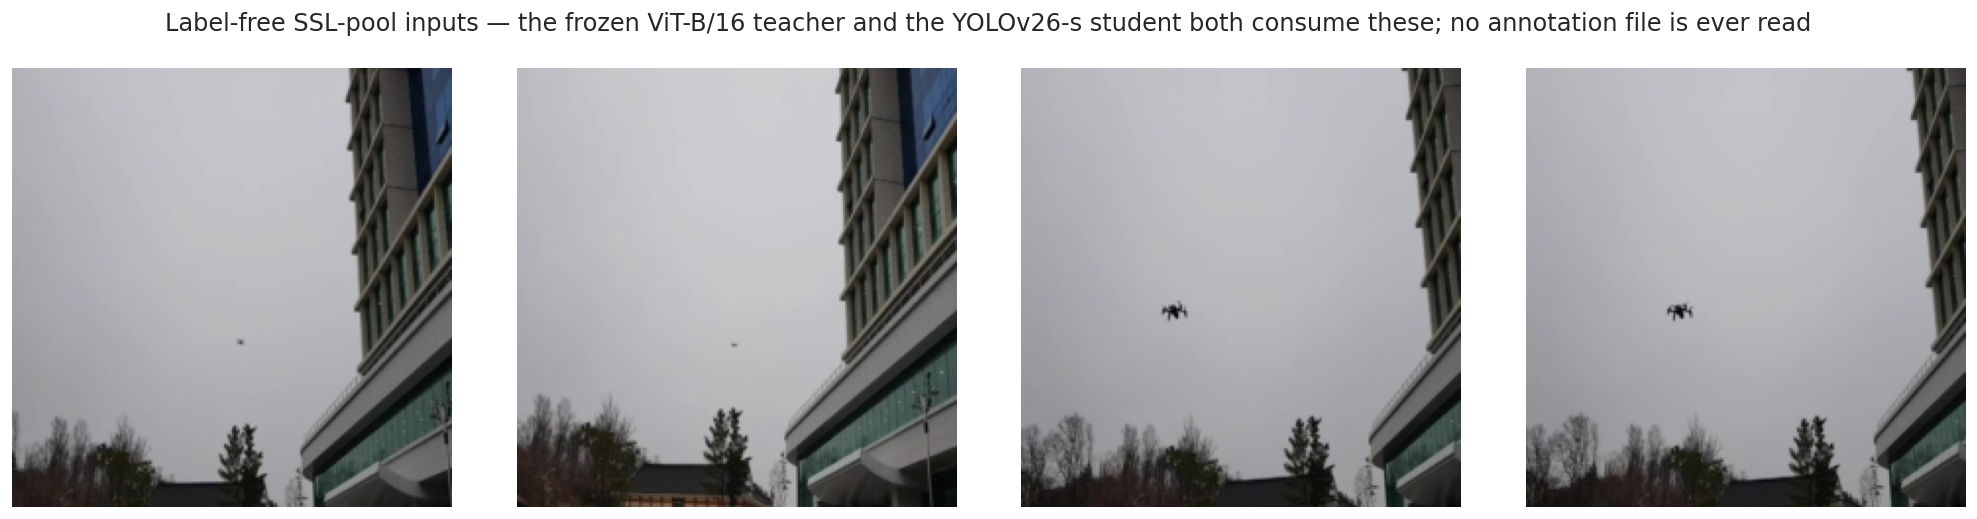

In [7]:
preview_transform = v2.Compose([
    v2.Resize((IMAGE_SIZE, IMAGE_SIZE), antialias=True),
    v2.ToImage(), v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(IMAGENET_MEAN, IMAGENET_STD)])
preview_dataset = UnlabeledImageDataset(pool_images, preview_transform)
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
fig, axes = plt.subplots(1, 4, figsize=(17, 4.4))
for k, ax in enumerate(axes):
    t = preview_dataset[k]
    ax.imshow((t * std + mean).clamp(0, 1).permute(1, 2, 0)); ax.axis("off")
fig.suptitle("Label-free SSL-pool inputs — the frozen ViT-B/16 teacher and the YOLOv26-s "
             "student both consume these; no annotation file is ever read")
plt.tight_layout(); plt.show()


## 6. Distillation Config + 1-Epoch Timing Probe
The probe measures one real epoch (teacher forward + student update over all 16,483 pool
images) and extrapolates ×30 before committing GPU-hours — the measure-first discipline
carried from Part A.

In [8]:
ssl_config = DINOv3YOLOConfig(
    data=str(SSL_POOL_DIR),
    output_dir=str(OUTPUT_DIR),
    teacher_weights=str(TEACHER_WEIGHTS),
    teacher_model=TEACHER_MODEL,
    student_model=STUDENT_MODEL,
    epochs=EPOCHS, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE,
    num_workers=WORKERS, devices=DEVICES, accelerator="gpu",
    precision=PRECISION, seed=PARTB_SEED,
    extra_arguments={"trainer_args": {"enable_model_summary": False}},
).validate()
print("DINOv3YOLOConfig validated | method:", ssl_config.method,
      "| teacher tokens:", f"{IMAGE_SIZE//16}x{IMAGE_SIZE//16} (ViT-B/16)")


DINOv3YOLOConfig validated | method: distillation | teacher tokens: 14x14 (ViT-B/16)


In [9]:
if TIMING_PROBE:
    probe_cfg = replace(ssl_config, epochs=1, output_dir=str(PROBE_DIR)).validate()
    t0 = time.time()
    pretrain_dinov3_yolo26(probe_cfg, module=lightly_train)
    probe_min = (time.time() - t0) / 60
    est = probe_min * EPOCHS
    print(f"\nProbe epoch: {probe_min:.1f} min -> {EPOCHS}-epoch estimate: "
          f"{est:.0f} min ({est/60:.1f} h)")
    print("[OK] Fits a single session." if est <= 9 * 60 else
          "[!] OVER BUDGET — documented levers, in order: BATCH_SIZE 32 -> 16 only if "
          "OOM (does not speed up), IMAGE_SIZE 224 -> 192, then an epochs reduction "
          "applied identically to ALL four SSL methods (assignment fairness rule).")
    shutil.rmtree(PROBE_DIR, ignore_errors=True)
else:
    print("Timing probe skipped (TIMING_PROBE=False).")


Args: {
    "accelerator": "gpu",
    "batch_size": 32,
    "callbacks": null,
    "checkpoint": null,
    "data": "/kaggle/working/ssl_pool",
    "devices": 1,
    "embed_dim": null,
    "epochs": 1,
    "float32_matmul_precision": "auto",
    "loader_args": null,
    "loggers": null,
    "method": "distillation",
    "method_args": {
        "teacher": "dinov3/vitb16",
        "teacher_weights": "/kaggle/input/datasets/mrifatrashid/dinov3-weigths/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth"
    },
    "model": "ultralytics/yolo26s.yaml",
    "model_args": null,
    "num_nodes": 1,
    "num_workers": 4,
    "optim": "auto",
    "optim_args": null,
    "out": "/kaggle/working/dinov3_probe",
    "overwrite": true,
    "precision": "16-mixed",
    "resume": null,
    "resume_interrupted": false,
    "seed": 445,
    "strategy": "auto",
    "trainer_args": {
        "enable_model_summary": false
    },
    "transform_args": {
        "image_size": [
            224,
            224
     

Training: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/module.py:1333: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate

`Trainer.fit` stopped: `max_epochs=1` reached.
Training completed.
Example: How to use the exported model
----------------------------------------------------------------------------------------
from ultralytics import YOLO

# Load the pretrained model
model = YOLO('/kaggle/working/dinov3_probe/exported_models/exported_last.pt')

# Finetune or evaluate the model
...
----------------------------------------------------------------------------------------

Model exported.



Probe epoch: 2.8 min -> 50-epoch estimate: 138 min (2.3 h)
[OK] Fits a single session.


## 7. Full Domain-Adaptive Distillation — 50 Epochs 

In [10]:
t0 = time.time()
training_result = pretrain_dinov3_yolo26(ssl_config, module=lightly_train)
TRAIN_MINUTES = (time.time() - t0) / 60
print(f"\nDistillation wall time: {TRAIN_MINUTES:.1f} min")
print(training_result)


Args: {
    "accelerator": "gpu",
    "batch_size": 32,
    "callbacks": null,
    "checkpoint": null,
    "data": "/kaggle/working/ssl_pool",
    "devices": 1,
    "embed_dim": null,
    "epochs": 50,
    "float32_matmul_precision": "auto",
    "loader_args": null,
    "loggers": null,
    "method": "distillation",
    "method_args": {
        "teacher": "dinov3/vitb16",
        "teacher_weights": "/kaggle/input/datasets/mrifatrashid/dinov3-weigths/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth"
    },
    "model": "ultralytics/yolo26s.yaml",
    "model_args": null,
    "num_nodes": 1,
    "num_workers": 4,
    "optim": "auto",
    "optim_args": null,
    "out": "/kaggle/working/dinov3_yolo26s_visiodect",
    "overwrite": true,
    "precision": "16-mixed",
    "resume": null,
    "resume_interrupted": false,
    "seed": 445,
    "strategy": "auto",
    "trainer_args": {
        "enable_model_summary": false
    },
    "transform_args": {
        "image_size": [
            224,
        

Training: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/module.py:1333: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate

`Trainer.fit` stopped: `max_epochs=50` reached.
Training completed.
Example: How to use the exported model
----------------------------------------------------------------------------------------
from ultralytics import YOLO

# Load the pretrained model
model = YOLO('/kaggle/working/dinov3_yolo26s_visiodect/exported_models/exported_last.pt')

# Finetune or evaluate the model
...
----------------------------------------------------------------------------------------

Model exported.



Distillation wall time: 97.1 min
DINOv3YOLOResult(output_dir=PosixPath('/kaggle/working/dinov3_yolo26s_visiodect'), training_checkpoint=PosixPath('/kaggle/working/dinov3_yolo26s_visiodect/checkpoints/last.ckpt'), yolo_checkpoint=PosixPath('/kaggle/working/dinov3_yolo26s_visiodect/exported_models/exported_last.pt'), metrics_jsonl=PosixPath('/kaggle/working/dinov3_yolo26s_visiodect/metrics.jsonl'), teacher_model='dinov3/vitb16', teacher_weights=PosixPath('/kaggle/input/datasets/mrifatrashid/dinov3-weigths/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth'), student_model='ultralytics/yolo26s.yaml')


### 7.1 Loss Curve and Checkpoints 
LightlyTrain streams metrics to `metrics.jsonl`; the parser below is schema-defensive
(plots every `*loss*` column it finds against epoch/step).

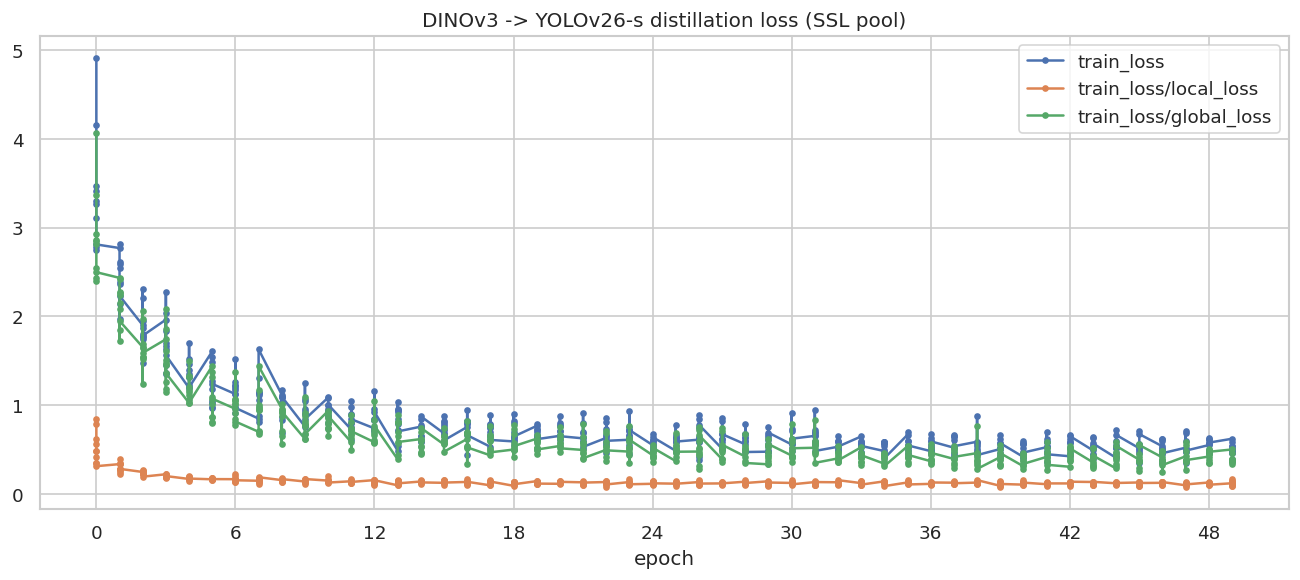

YOLO student checkpoint    /kaggle/working/dinov3_yolo26s_visiodect/expor...
Lightly checkpoint         /kaggle/working/dinov3_yolo26s_visiodect/check...
teacher                                                        dinov3/vitb16
teacher weights            /kaggle/input/datasets/mrifatrashid/dinov3-wei...
unlabelled images                                                      16483
dtype: object


In [11]:
YOLO_CHECKPOINT   = training_result.yolo_checkpoint
LIGHTLY_CHECKPOINT = training_result.training_checkpoint
records = []
if training_result.metrics_jsonl.is_file():
    for ln in training_result.metrics_jsonl.read_text().splitlines():
        if ln.strip():
            records.append(json.loads(ln))
metrics = pd.json_normalize(records)
loss_cols = [c for c in metrics.columns if "loss" in c.lower()]
x_col = next((c for c in ("epoch", "step") if c in metrics.columns), None)
if loss_cols:
    fig, ax = plt.subplots(figsize=(11, 5))
    for c in loss_cols:
        s = metrics[[x_col, c]].dropna() if x_col else metrics[[c]].dropna().reset_index()
        ax.plot(s.iloc[:, 0], s[c], marker="o", ms=3, label=c)
    ax.set_title("DINOv3 -> YOLOv26-s distillation loss (SSL pool)")
    ax.set_xlabel(x_col or "record"); ax.legend()
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.tight_layout()
    plt.savefig(f"{WORK_ROOT}/dinov3_loss_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No loss columns found; metrics tail:"); display(metrics.tail())

print(pd.Series({
    "YOLO student checkpoint": str(YOLO_CHECKPOINT),
    "Lightly checkpoint": str(LIGHTLY_CHECKPOINT),
    "teacher": training_result.teacher_model,
    "teacher weights": str(training_result.teacher_weights),
    "unlabelled images": len(pool_images),
}))


## 8. Representation Diagnostics 
Embeddings are extracted for a **500-image sample of the validation partition** (never seen
during pretraining) with the trained backbone. VisioDECT's filenames encode
`Class_scenario_original`, so the t-SNE can be coloured two ways — by **drone class** (does
the representation organise target-class content?) and by **scenario** (or does it organise
by lighting instead — an equally honest finding). The retrieval panels and a quantitative
top-5 neighbour class-agreement score back the visual impression. The comparison to keep in mind for the report: the same panels for I-JEPA (Notebook 3a) scored 95.0% class / 97.5% scenario agreement — does inherited web-scale semantics beat from-scratch latent prediction? Labels are used here for
**colouring diagnostics only, after training** — pretraining never saw them.

In [12]:
SCENARIOS = ["cloudy", "evening", "sunny"]
CLASS_NAMES = ["Anafi", "DJI_FPV", "DJI_Phantom", "EFT_E410S", "Mavic_Air", "Mavic_Enterprise"]

def parse_stem(stem):
    for c in sorted(CLASS_NAMES, key=len, reverse=True):
        if stem.startswith(c + "_"):
            rest = stem[len(c) + 1:]
            scen = rest.split("_")[0]
            return c, scen if scen in SCENARIOS else "unknown"
    return "unknown", "unknown"

val_rows = partition[partition.partition == "val"]
sel = val_rows.sample(min(500, len(val_rows)), random_state=PARTB_SEED)
sel_paths  = [Path(p) for p in sel.source_path]
sel_class  = [parse_stem(Path(p).stem)[0] for p in sel.source_path]
sel_scen   = [parse_stem(Path(p).stem)[1] for p in sel.source_path]

feature_transform = v2.Compose([
    v2.Resize(IMAGE_SIZE + 32, antialias=True),
    v2.CenterCrop(IMAGE_SIZE),
    v2.ToImage(), v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

class FeatureDataset(Dataset):
    def __len__(self):
        return len(sel_paths)
    def __getitem__(self, i):
        with Image.open(sel_paths[i]) as im:
            return feature_transform(im.convert("RGB")), i

encoder = YOLOBackboneEncoder(YOLO(str(YOLO_CHECKPOINT)).model).to(DEVICE).eval()
loader = DataLoader(FeatureDataset(), batch_size=64, shuffle=False,
                    num_workers=min(2, WORKERS), pin_memory=DEVICE.type == "cuda")
feats = []
amp_ctx = torch.amp.autocast("cuda") if DEVICE.type == "cuda" else torch.amp.autocast("cpu", enabled=False)
with torch.inference_mode(), amp_ctx:
    for images, _ in tqdm(loader, desc="extracting DINOv3-student features (val sample)"):
        f = encoder(images.to(DEVICE, non_blocking=True))
        feats.append(F.normalize(f.float(), dim=1).cpu())
feature_matrix = torch.cat(feats)
print(f"features: {tuple(feature_matrix.shape)} | "
      f"mean per-dim std: {feature_matrix.std(dim=0).mean():.4f} "
      "(a healthy non-collapsed representation has clearly non-zero spread)")


extracting DINOv3-student features (val sample):   0%|          | 0/8 [00:00<?, ?it/s]

features: (500, 512) | mean per-dim std: 0.0282 (a healthy non-collapsed representation has clearly non-zero spread)


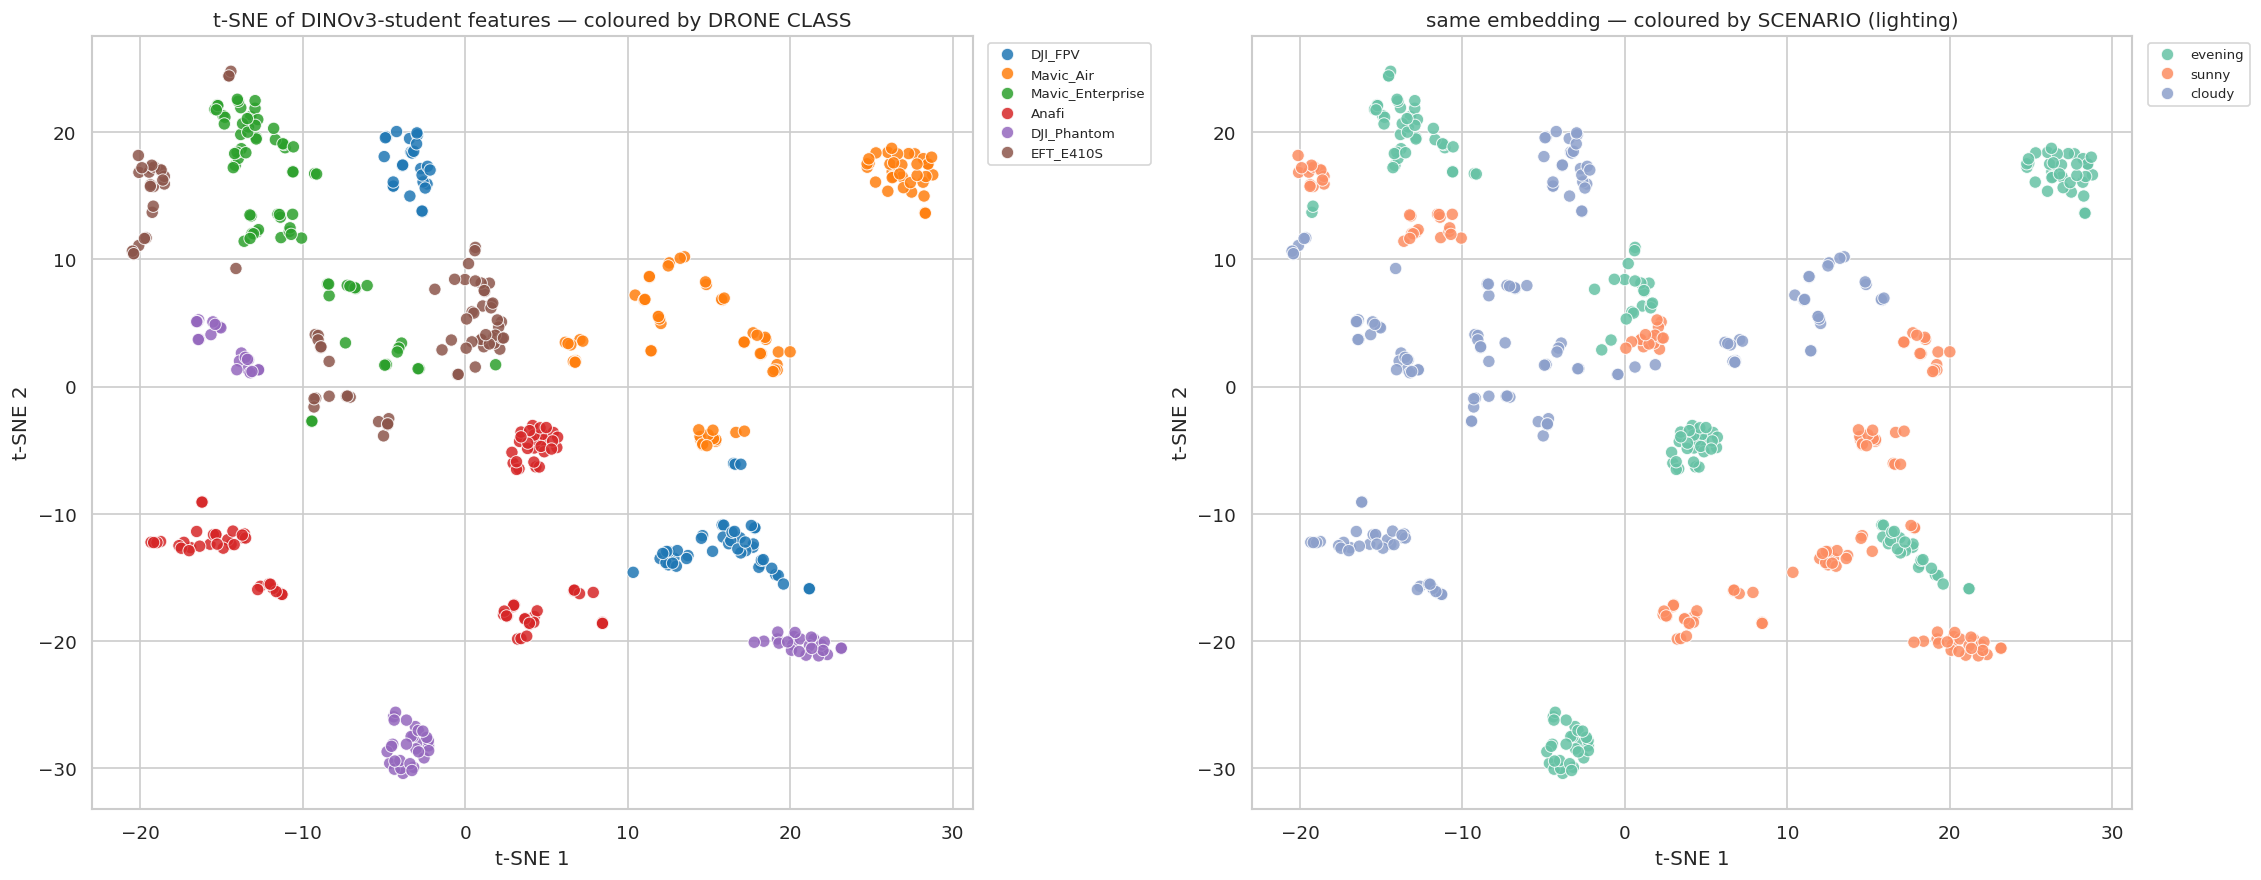

top-5 neighbour agreement — class: 97.2% (chance ~16.7%) | scenario: 97.2% (chance ~33.3%)


In [13]:
# ---- t-SNE coloured by class AND by scenario --------------------------------
perp = min(30.0, max(2.0, (len(feature_matrix) - 1) / 3))
coords = TSNE(n_components=2, perplexity=perp, learning_rate="auto",
              init="pca", max_iter=1000, random_state=PARTB_SEED
              ).fit_transform(feature_matrix.numpy())
frame = pd.DataFrame({"t-SNE 1": coords[:, 0], "t-SNE 2": coords[:, 1],
                      "class": sel_class, "scenario": sel_scen})
fig, axes = plt.subplots(1, 2, figsize=(19, 7.5))
sns.scatterplot(data=frame, x="t-SNE 1", y="t-SNE 2", hue="class",
                palette="tab10", s=55, alpha=0.85, ax=axes[0])
axes[0].set_title("t-SNE of DINOv3-student features — coloured by DRONE CLASS")
sns.scatterplot(data=frame, x="t-SNE 1", y="t-SNE 2", hue="scenario",
                palette="Set2", s=55, alpha=0.85, ax=axes[1])
axes[1].set_title("same embedding — coloured by SCENARIO (lighting)")
for ax in axes:
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(f"{WORK_ROOT}/dinov3_tsne.png", dpi=150, bbox_inches="tight")
plt.show()

# quantitative check: do top-5 neighbours share the query's class?
sims = feature_matrix @ feature_matrix.T
sims.fill_diagonal_(-1)
top5 = sims.topk(5, dim=1).indices
agree = np.mean([[sel_class[j] == sel_class[i] for j in row.tolist()]
                 for i, row in enumerate(top5)])
scen_agree = np.mean([[sel_scen[j] == sel_scen[i] for j in row.tolist()]
                      for i, row in enumerate(top5)])
print(f"top-5 neighbour agreement — class: {agree:.1%} (chance ~16.7%) | "
      f"scenario: {scen_agree:.1%} (chance ~33.3%)")


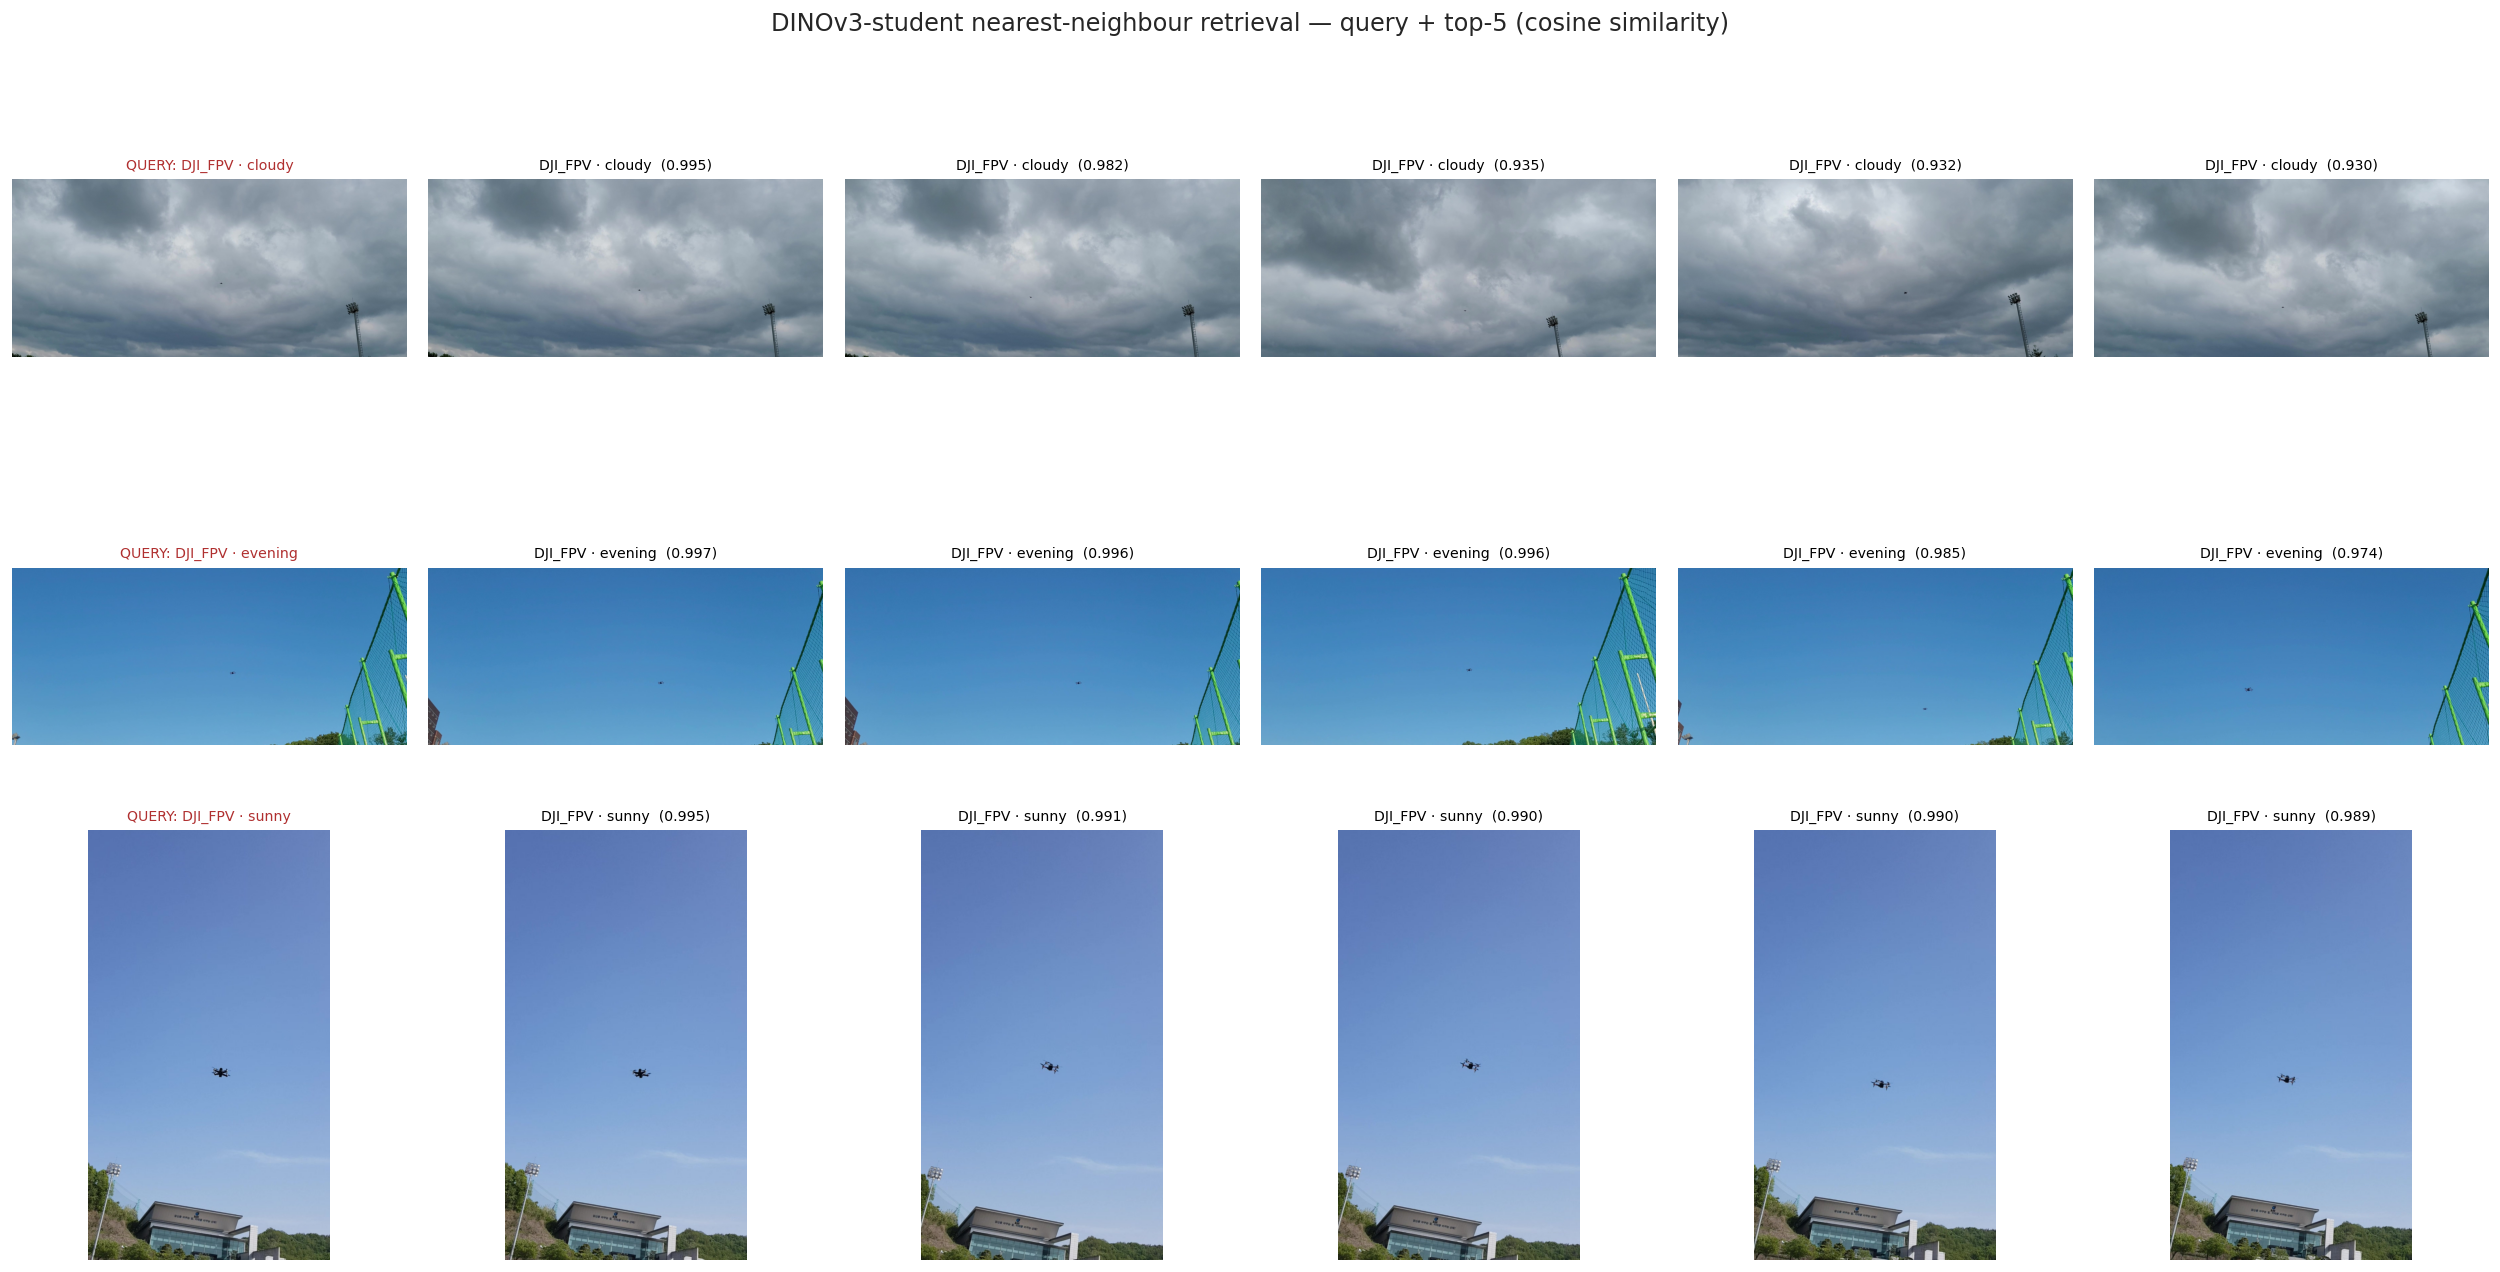

In [14]:
# ---- nearest-neighbour retrieval panels (one query per scenario) ------------
queries = [i for scen in SCENARIOS
           for i in [next((k for k, s in enumerate(sel_scen) if s == scen), None)]
           if i is not None] or [0]
fig, axes = plt.subplots(len(queries), 6, figsize=(21, 3.6 * len(queries)))
axes = np.atleast_2d(axes)
for row, q in enumerate(queries):
    nn = [j for j in sims[q].topk(6).indices.tolist() if j != q][:5]
    for col, idx in enumerate([q] + nn):
        ax = axes[row, col]
        with Image.open(sel_paths[idx]) as im:
            ax.imshow(im.convert("RGB"))
        ax.axis("off")
        ax.set_title("QUERY: " + f"{sel_class[idx]} · {sel_scen[idx]}" if col == 0
                     else f"{sel_class[idx]} · {sel_scen[idx]}  ({sims[q][idx]:.3f})",
                     fontsize=8.5, color="#b03030" if col == 0 else "black")
plt.suptitle("DINOv3-student nearest-neighbour retrieval — query + top-5 (cosine similarity)")
plt.tight_layout()
plt.savefig(f"{WORK_ROOT}/dinov3_retrieval.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Checkpoint Export + Kaggle Dataset Hand-off 
| File in `/kaggle/working/` | Purpose |
|---|---|
| **`dinov3_backbone.pt`** | §7-convention SSL checkpoint (the exported YOLO student) |
| **`dinov3_yolo26s_backbone.pt`** | Same student under the 4b-discovery name — 4b's weight surgery loads this |
| `partB_partition.csv` | The shared partition (byte-identical to 3a's — diffable proof) |
| `dinov3_loss_curve.png`, `dinov3_tsne.png`, `dinov3_retrieval.png` | Report figures |
| `dinov3_yolo26s_visiodect/` | Full LightlyTrain run dir (metrics.jsonl, checkpoints/last.ckpt) |


In [15]:
shutil.copy2(YOLO_CHECKPOINT, CKPT_BACKBONE)
shutil.copy2(YOLO_CHECKPOINT, CKPT_YOLO)
summary = {
    "method": SSL_METHOD,
    "route": "distillation into CNN (frozen dinov3/vitb16 teacher, released "
             "LVD-1689M weights -> domain-adaptive on the VisioDECT pool)",
    "student": STUDENT_MODEL, "epochs": EPOCHS, "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE, "precision": PRECISION, "devices": DEVICES,
    "seed": PARTB_SEED, "ssl_pool_images": len(pool_images),
    "train_minutes": round(TRAIN_MINUTES, 1),
    "checkpoint_backbone": CKPT_BACKBONE, "checkpoint_yolo": CKPT_YOLO,
    "partition_manifest": PARTITION_CSV,
}
Path(f"{WORK_ROOT}/dinov3_pretrain_summary.json").write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))
for f in [CKPT_BACKBONE, CKPT_YOLO, PARTITION_CSV]:
    q = Path(f)
    print(f"[OK] {q.name:<32} {q.stat().st_size/1e6:>8.1f} MB" if q.exists() else f"MISSING {f}")


{
  "method": "dinov3",
  "route": "distillation into CNN (frozen dinov3/vitb16 teacher, released LVD-1689M weights -> domain-adaptive on the VisioDECT pool)",
  "student": "ultralytics/yolo26s.yaml",
  "epochs": 50,
  "image_size": 224,
  "batch_size": 32,
  "precision": "16-mixed",
  "devices": 1,
  "seed": 445,
  "ssl_pool_images": 16483,
  "train_minutes": 97.1,
  "checkpoint_backbone": "/kaggle/working/dinov3_backbone.pt",
  "checkpoint_yolo": "/kaggle/working/dinov3_yolo26s_backbone.pt",
  "partition_manifest": "/kaggle/working/partB_partition.csv"
}
[OK] dinov3_backbone.pt                   20.4 MB
[OK] dinov3_yolo26s_backbone.pt           20.4 MB
[OK] partB_partition.csv                   4.6 MB


## 10. Pre-Commit Checklist 
- [ ] Install cell printed **ssl-detection-lab version >= 0.8.1**; support table all True
- [ ] Partition sizes + disjointness `[OK]` (byte-identical to 3a's manifest)
- [ ] Preview inputs, probe estimate, distillation loss curve visible
- [ ] t-SNE (class + scenario), retrieval panels, agreement percentages visible; §8.1 written
- [ ] `dinov3_backbone.pt`, `dinov3_yolo26s_backbone.pt`, `partB_partition.csv` printed `[OK]`
- [ ] Committed Public; files added to the checkpoint dataset for 4b
